# DEIMoS -- Manual Wie Regulator Gain Tuning

Hand-tune the Wie/Weiss/Arapostathis (1989) quaternion regulator
(`control/wie.py`) by editing one cell and re-running: simulate, look at the
plots and numbers, adjust, repeat. There is no automated-search counterpart
to `tune_pid.ipynb` for this law yet -- the NSGA-II search in
`tuning/objectives.py` only covers the eigenaxis case (`k_scale`/`d_scale`),
not the other three -- so this notebook is the primary way to tune cases
2-4, and a faster iteration loop than the search for case 1 too.

**The law** (see `control/wie.py` for the full derivation):

    u = mu*(omega x J*omega) - D @ omega - sgn(q_e0) * (K @ q_ev)

Four cases trade off eigenaxis-optimality against robustness to inertia
error, all from the *same* (`zeta`, `settling_time_s`) sizing rule:

| case | K | mu | property |
|---|---|---|---|
| `eigenaxis` | `k*J` | 1 | shortest angular path, needs accurate J |
| `robust` | `k*I` | 0 | globally stable under unknown Delta_J, gives up eigenaxis |
| `mortensen` | `k/diag(J)` | 0 | Remark 1 extreme (beta=0) |
| `near_eigenaxis` | fitted `K^-1 = alpha*J + beta*I` | 0 | least-squares compromise of the two above |

**Tuning heuristics:**

| Symptom | Try |
|---|---|
| Responds too slowly | shorten `settling_time_s` (raises omega_n, so both `k` and `d`) |
| Overshoots / rings | raise `zeta` towards/above 1.0 (critically/over-damped) |
| Wheels saturate (see the saturation plot) | lengthen `settling_time_s`, or accept slower response |
| Path visibly bows off the direct route (`eigenaxis_deviation` plot) | you are not in `case="eigenaxis"`, or `decouple_wheel_momentum` is off -- see below |
| Small persistent offset under a disturbance | add `Ki` -- but see below |

**`decouple_wheel_momentum` -- required for `case="eigenaxis"` on this plant.**
The paper assumes an ideal torque actuator; DEIMoS is a momentum-exchange
system, so `mu=1` alone cancels only the *body* part of the gyroscopic term
and leaves `-omega x h_w` -- not along the error eigenaxis, and it grows
through the slew because `h_w` is exactly what the wheels accumulate to
perform it. Measured on the 40/30/25 deg slew: 3.65 deg mean eigenaxis
deviation with the flag off, 0.005 deg with it on. Leave this `True` unless
you deliberately want to reproduce the paper's ideal-actuator assumption.

**On `Ki`:** the Sec. III global-stability proof covers `mu`/`K`/`D` only --
integral action is a heuristic addition on top, same caveat as the PID
notebook. When you do add it, `Ki = ki * diag(J)` (a ratio of `k`, not a flat
per-axis vector) keeps the integral term proportional to `J` the same way
`K` and `D` are, so it does not reintroduce an inertia-mismatched term into
an otherwise J-matched design -- see `tuning/objectives.py:_apply_wie_gains`
for the same reasoning applied by the automated search. Always pair it with
`integral_limit`, for the same windup reason as the PID notebook.

**Two ways to set (K, D):** the sizing rule (`case`/`zeta`/`settling_time_s`,
all four cases) or, for `case="eigenaxis"` only, direct scale factors
(`k_scale`/`d_scale`, i.e. `K = k_scale*J`, `D = d_scale*J`, `mu=1`) --
useful once you want to move off the `t_s = 8/(zeta*omega_n)` curve, which
is a linearized/unsaturated estimate, not a hard constraint. Section 4
below has a `FORM` switch between the two.

## 1 -- Setup

In [1]:
import copy
from pathlib import Path

import numpy as np

from deimos.sim.config import compose_config
from deimos.sim.runner import simulate
from deimos.analysis.design_card import describe
from deimos.analysis.stability import stability_branch
from deimos.control.wie import WieRegulator
from deimos.dynamics.disturbances import gravity_gradient_torque
from deimos.viz.single_run import plot
from deimos.viz.comparison import compare, comparison_table

np.set_printoptions(precision=6, suppress=False, linewidth=110)

## 2 -- Scenario

The plant and maneuver -- not what you're tuning, just what you're tuning
against. `SEED_CONTROLLER_YAML` only supplies the `type: wie` scaffold;
every gain it carries is overwritten in §4.

In [2]:
SCENARIO_YAML = "../configs/scenarios/slew_160_40_30.yaml"
SEED_CONTROLLER_YAML = "../configs/controllers/wie_eigenaxis.yaml"  # only used for its type=wie scaffold

base = compose_config(SCENARIO_YAML, SEED_CONTROLLER_YAML)
J = base.satellite.inertia_tensor
print(f"scenario     : {Path(SCENARIO_YAML).stem}")
print(f"wheel config : {base.wheels.config}, max_torque={base.wheels.max_torque:.2e} N m, max_speed={base.wheels.max_speed:.1f} rad/s")
print(f"inertia J diag: {np.diag(J)}")

scenario     : slew_160_40_30
wheel config : cone, max_torque=4.00e-03 N m, max_speed=1256.6 rad/s
inertia J diag: [0.03605 0.0345  0.01016]


## 3 -- Disturbance (optional)

`Ki` only has something to reject against a persistent bias. Toggle this on
to actually exercise the integral term; off to check the slew transient
alone.

In [3]:
USE_GRAVITY_GRADIENT = False

base = copy.deepcopy(base)
if USE_GRAVITY_GRADIENT:
    tau_gg = gravity_gradient_torque(J)
    base.disturbance.enabled = True
    base.disturbance.constant_torque = np.full(3, tau_gg)
    print(f"disturbance: gravity-gradient, {tau_gg:.4e} N m per axis")
else:
    base.disturbance.enabled = False
    print("disturbance: none")

disturbance: none


## 4 -- THE GAINS -- edit this cell and re-run from here

`CASE` picks the row of the table in §0. `FORM` picks how `(K, D)` are
built:

- `"rule"` -- `zeta`/`settling_time_s`, works for all four cases (the human
  way to specify "critically damped, settle in N seconds").
- `"direct"` -- `k_scale`/`d_scale`, i.e. `K = k_scale*J`, `D = d_scale*J`,
  `mu = 1`. **`case="eigenaxis"` only** -- cases 2-4 have no single scale
  factor for `K`, so `build_wie_from_config` raises if you combine this with
  another case (see `control/wie.py`).

`integral_limit` caps `Ki`'s *contribution* at this many N m -- set it to a
fraction of `base.wheels.max_torque` printed above. `KI_RATIO = None` keeps
the base case (no integral action), matching every existing Wie preset.

In [4]:
CASE = "eigenaxis"          # eigenaxis | robust | mortensen | near_eigenaxis
FORM = "rule"                # "rule" (zeta/settling_time_s) or "direct" (k_scale/d_scale, eigenaxis only)

# --- rule form (all cases) ---
ZETA = 1.0                   # damping ratio
SETTLING_TIME_S = 30.0       # large-angle settling time, t_s = 8/(zeta*omega_n)

# --- direct form (FORM="direct", CASE must be "eigenaxis") ---
K_SCALE = 1.75717               # K = k_scale * J
D_SCALE = 0.381016            # D = d_scale * J

DECOUPLE_WHEEL_MOMENTUM = True   # required for CASE="eigenaxis" to actually be eigenaxis
                                  # on this momentum-exchange plant -- see §0 / control/wie.py

KI_RATIO =  [1.1536e-04, 1.1040e-04, 3.2512e-05]            # None, or ki such that Ki = ki * diag(J) -- try 1e-4 to 1e-1 * k/d
INTEGRAL_LIMIT = 0.25 * base.wheels.max_torque    # or None
U_MAX = None                        # optional flat per-axis command clip, N m
DURATION = 240            # simulated seconds

cfg = copy.deepcopy(base)
cfg.sim.duration = DURATION
cfg.controller.type = "wie"
cfg.controller.case = CASE
cfg.controller.decouple_wheel_momentum = DECOUPLE_WHEEL_MOMENTUM
cfg.controller.Ki = None if KI_RATIO is None else KI_RATIO * np.diag(J)
cfg.controller.integral_limit = INTEGRAL_LIMIT
cfg.controller.u_max = U_MAX
cfg.name = "manual"

if FORM == "rule":
    cfg.controller.zeta = ZETA
    cfg.controller.settling_time_s = SETTLING_TIME_S
    cfg.controller.k_scale = None
    cfg.controller.d_scale = None
elif FORM == "direct":
    cfg.controller.zeta = None
    cfg.controller.settling_time_s = None
    cfg.controller.k_scale = K_SCALE
    cfg.controller.d_scale = D_SCALE
else:
    raise ValueError(f"unknown FORM '{FORM}'")

results = simulate(cfg)

# describe() derives its printout from zeta/settling_time_s, so it only
# renders for FORM="rule"; the direct form prints the equivalent numbers
# (K, D, mu and the same Sec. III stability verdict) by hand instead.
if FORM == "rule":
    print(describe(cfg))
else:
    K, D, mu = WieRegulator.eigenaxis_gains(J, k=K_SCALE, d=D_SCALE)
    status, detail, _ = stability_branch(K, D, J, mu)
    print(f"K = {K_SCALE:.4g} * J, D = {D_SCALE:.4g} * J, mu = {mu}")
    print(f"\nGLOBAL STABILITY: {status}\n  {detail}")
print(results.summary())

CONTROLLER DESIGN CARD - manual

PLANT
  inertia tensor J [kg m^2] (CoM-referenced):
    [ 3.605000e-02  -1.306888e-05  -2.074916e-05]
    [-1.306888e-05   3.450000e-02   5.884415e-05]
    [-2.074916e-05   5.884415e-05   1.016000e-02]
  principal moments diag(J) : [0.03605 0.0345  0.01016]
  max |off-diagonal| / min diag : 5.79e-03 (diagonal-dominant)
  off-diagonal/diag ratio = 1.77e-03 is under the 1% threshold => design()'s diag(J)-only fit (mortensen, near_eigenaxis) is justified for this J.

ACTUATORS
  ReactionWheelArray(N=3, Iw=5.80e-06 kg m^2, max_torque=4.00e-03 N m, max_speed=1256.6 rad/s)
  max deliverable body torque per axis [N m]: [0.0057 0.0049 0.0069]
    (= max_torque / |W^+ n|_inf, i.e. the real actuator ceiling,
     not N x the per-wheel limit)

CONTROL LAW - Wie, Weiss & Arapostathis (1989), Sec. III
  u = mu*(omega x J*omega) - D*omega - sgn(q_e0)*K*q_ev
  case  : eigenaxis
  design: zeta = 1.0, t_settle = 30.0 s -> omega_n = 8/(zeta*t_s) = 0.2667 rad/s
  mu    : 

## 5 -- Look at it

`attitude_error` / `body_rates` -- did it converge, how fast.
`control_torque` / `torque_envelope` -- what it's asking the wheels for.
`saturation` -- the diagnostic for "back off the gains", per the table in
§0. `error_quaternion` -- a slow un-damping wobble after the slew settles
is the limit-cycle signature of `Ki` too large / windup.
`eigenaxis_deviation` -- THE diagnostic specific to this controller: how far
`omega` strays from the initial error eigenaxis. Near zero only for
`case="eigenaxis"` with `decouple_wheel_momentum=True`; cases 2-4 are
expected to show real deviation, that is the property they trade away for
robustness.

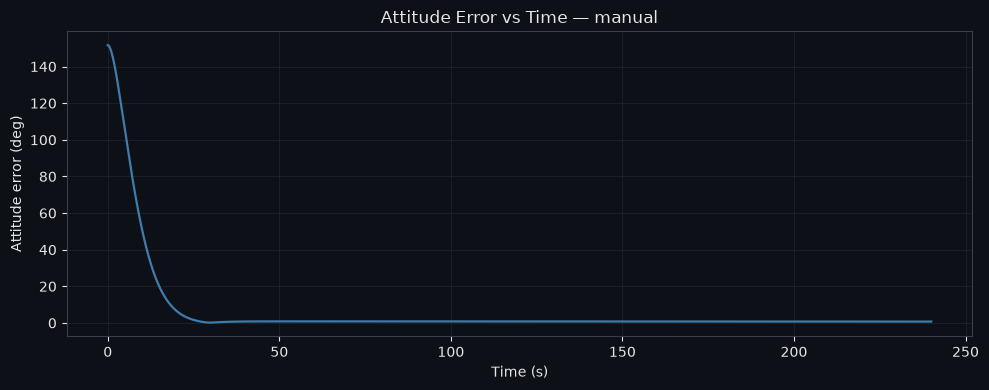

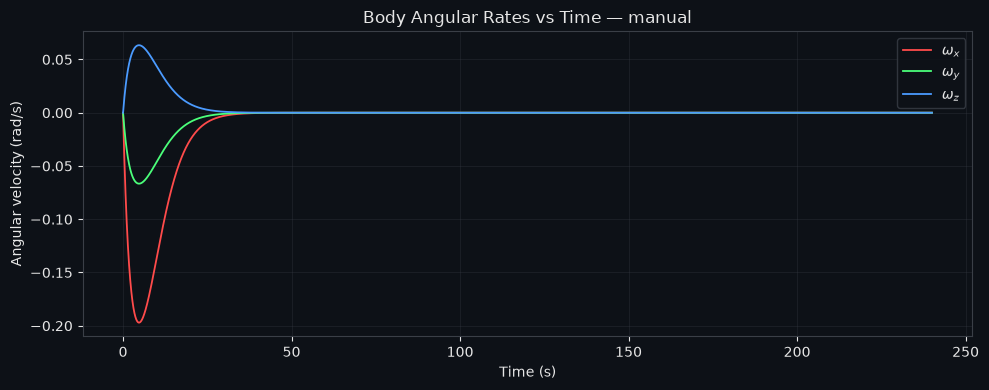

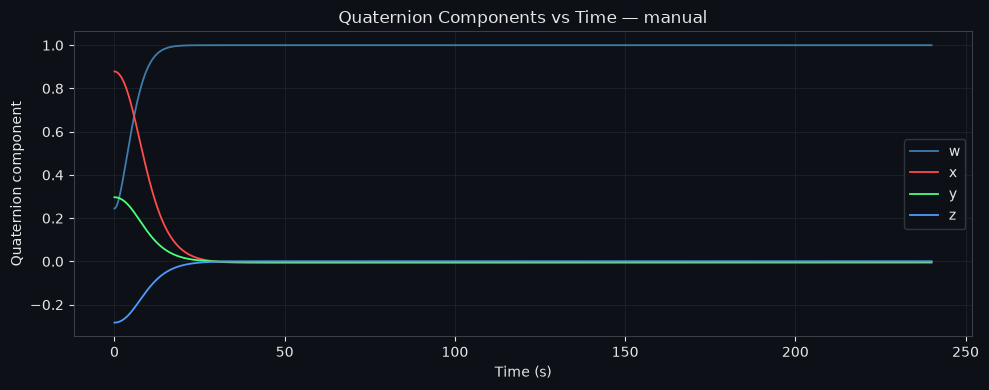

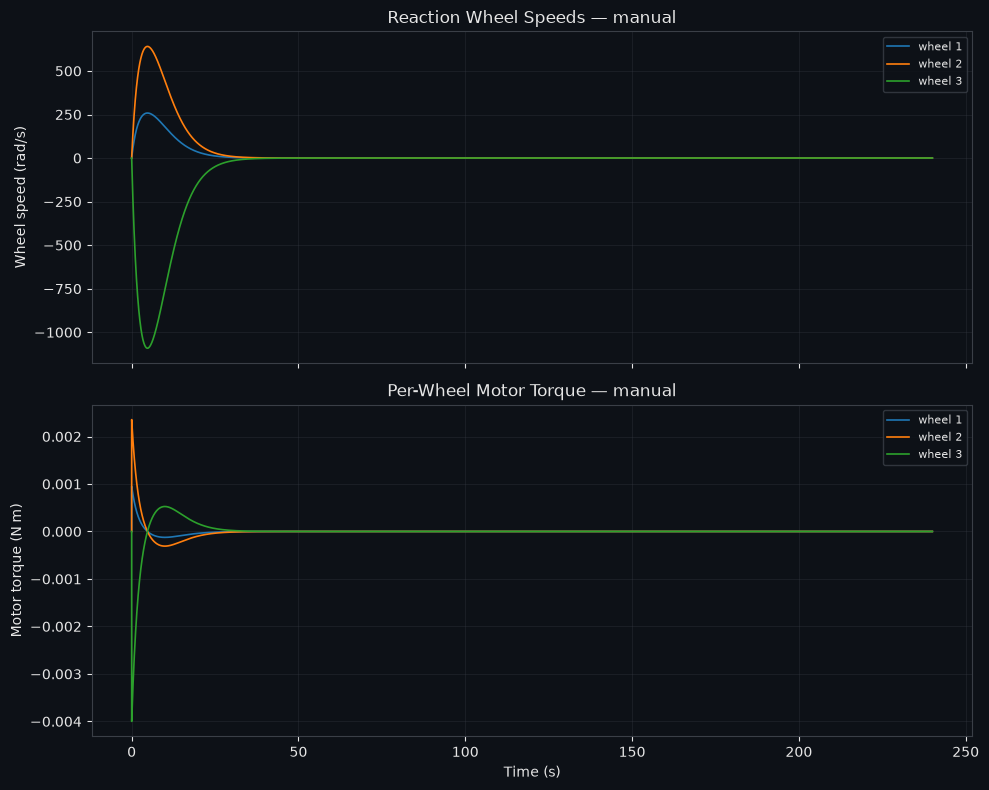

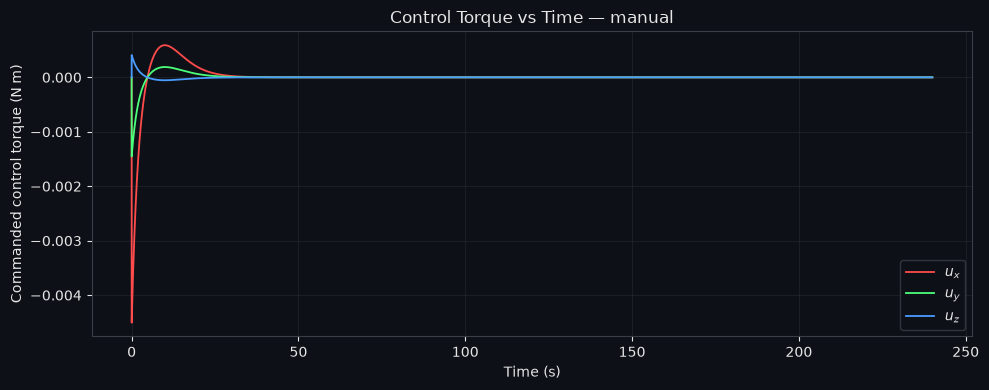

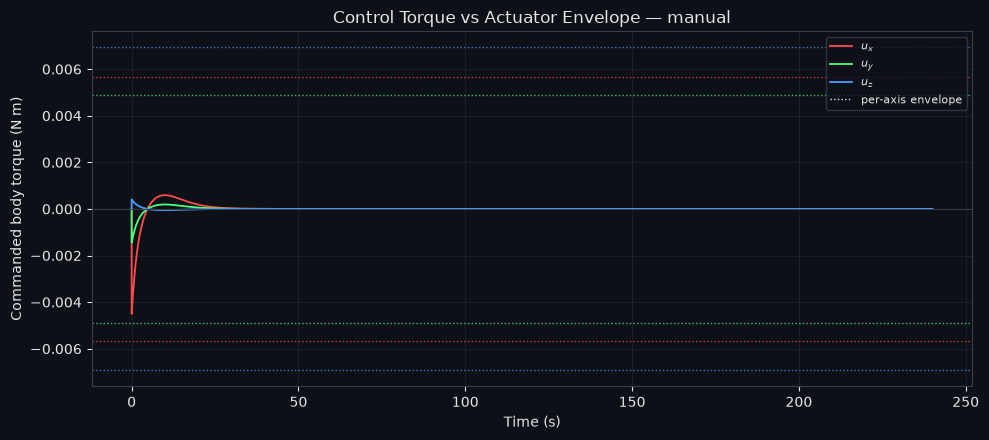

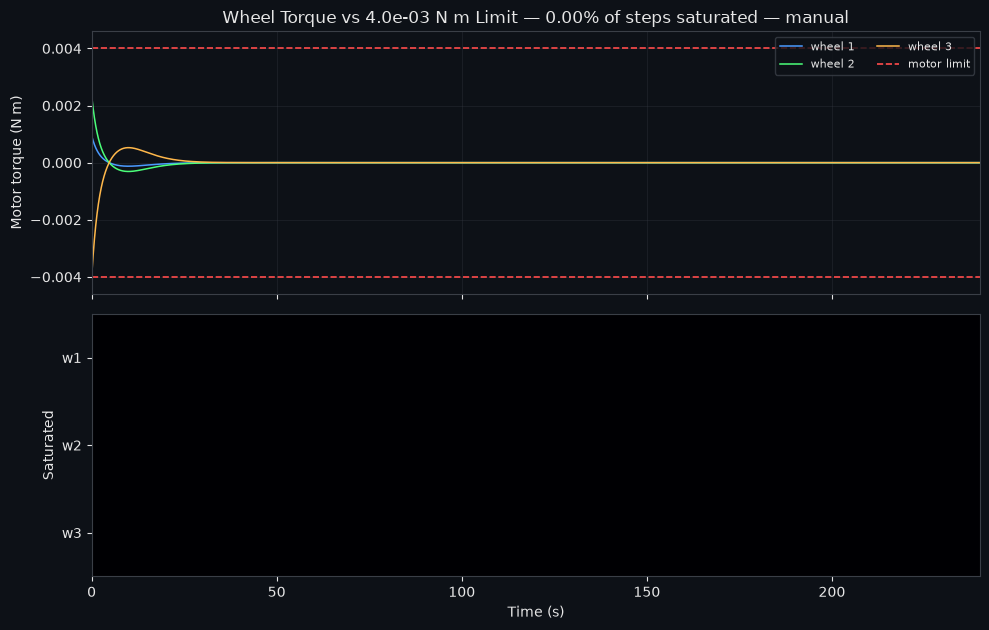

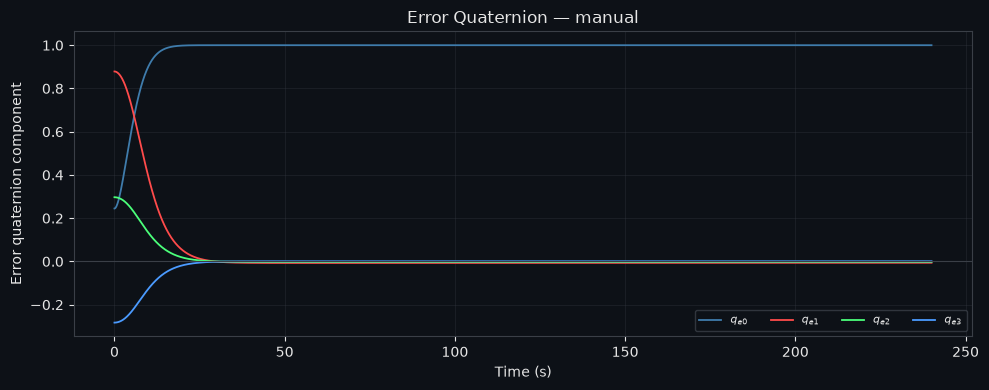

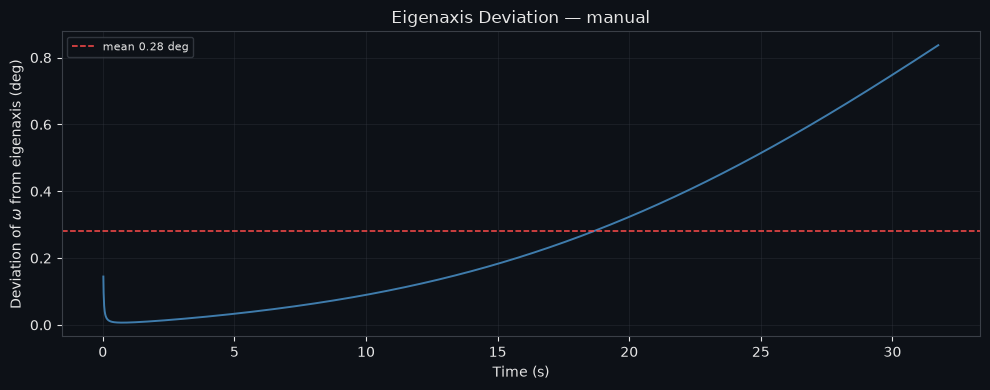

In [5]:
_ = plot(results, names=["attitude_error", "body_rates", "quaternion_components", "wheel_panel",
                          "control_torque", "torque_envelope", "saturation", "error_quaternion",
                          "eigenaxis_deviation"])

## 6 -- Keep this attempt (optional)

Run this cell to snapshot the current gains and stability verdict under a
label, then go back to §4, change something, and re-run §4-§5.
Snapshots accumulate in `attempts` until you compare them in §7.

In [6]:
if "attempts" not in globals():
    attempts = {}
    attempt_stability = {}

if FORM == "rule":
    tag = f"{CASE} zeta={ZETA:g} ts={SETTLING_TIME_S:g}s"
    K, D, mu = WieRegulator.design(J, case=CASE, zeta=ZETA, settling_time=SETTLING_TIME_S)
else:
    tag = f"{CASE} k={K_SCALE:g} d={D_SCALE:g}"
    K, D, mu = WieRegulator.eigenaxis_gains(J, k=K_SCALE, d=D_SCALE)
if KI_RATIO is not None:
    tag += f" ki={KI_RATIO:.2g}"

status, _, _ = stability_branch(K, D, J, mu)

LABEL = tag
attempts[LABEL] = results
attempt_stability[LABEL] = status
print(f"kept '{LABEL}'  [{status}]  ({len(attempts)} attempt(s) so far)")

TypeError: unsupported format string passed to list.__format__

## 7 -- Compare every kept attempt

In [ ]:
assert attempts, "nothing kept yet -- run section 6 at least once"
print(comparison_table(attempts, stability=attempt_stability))
_ = compare(attempts, names="all")

## 8 -- Export the gains you're happy with

Prints a ready-to-paste `controller:` YAML block and writes it to
`configs/controllers/`. Re-run §4 with the gains you want first, this
exports whatever `cfg`/`CASE`/`FORM`/gain variables currently hold.

In [ ]:
OUTPUT_CONTROLLER_YAML = f"../configs/controllers/wie_manual_{Path(SCENARIO_YAML).stem}.yaml"

lines = [
    f"# Hand-tuned in studies/tune_wie_manual.ipynb -- scenario={Path(SCENARIO_YAML).stem}",
    "controller:",
    "  type: wie",
    f"  case: {CASE}",
]
if FORM == "rule":
    lines += [
        f"  zeta: {ZETA:.6g}",
        f"  settling_time_s: {SETTLING_TIME_S:.6g}",
    ]
else:
    lines += [
        f"  k_scale: {K_SCALE:.6e}",
        f"  d_scale: {D_SCALE:.6e}",
    ]
lines.append(f"  decouple_wheel_momentum: {str(DECOUPLE_WHEEL_MOMENTUM).lower()}")
if KI_RATIO is None:
    lines.append("  # Ki: none -- base case, per the Sec. III proof")
else:
    Ki_vec = KI_RATIO * np.diag(J)
    lines.append(f"  Ki: [{Ki_vec[0]:.6e}, {Ki_vec[1]:.6e}, {Ki_vec[2]:.6e}]")
    if INTEGRAL_LIMIT is not None:
        lines.append(f"  integral_limit: {INTEGRAL_LIMIT:.6e}")
if U_MAX is not None:
    lines.append(f"  u_max: {U_MAX:.6e}")

yaml_block = "\n".join(lines) + "\n"
print(yaml_block)

Path(OUTPUT_CONTROLLER_YAML).parent.mkdir(parents=True, exist_ok=True)
Path(OUTPUT_CONTROLLER_YAML).write_text(yaml_block)
print(f"wrote {OUTPUT_CONTROLLER_YAML}")